# Dataset Exploration

Week 2 dataset inspection for the HiRISE cross-validation image dataset. This notebook verifies the local folder structure against the provided cross-validation workbook and produces summary outputs for later training and reporting.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_inspection import DATA_ROOT, SPLIT_WORKBOOK, run_inspection

## Paths

The image dataset is kept locally in `data/raw/` and is not intended to be committed to GitHub. The split workbook is used as the reference for expected fold/class counts.

In [2]:
DATA_ROOT, SPLIT_WORKBOOK

(WindowsPath('C:/Users/Jacob/GitHub/DellSummerResearch/data/raw/HiRISE Data'),
 WindowsPath('C:/Users/Jacob/GitHub/DellSummerResearch/data/splits/HiRise data - cross-validation - 7 versions (version 1).xlsx'))

## Build Inventory

This scans local image paths, records labels/splits/folds, opens each image to confirm readability, and saves CSV summaries in `outputs/metrics/`.

In [3]:
inventory, expected_counts, comparison = run_inspection(
    data_root=DATA_ROOT,
    workbook_path=SPLIT_WORKBOOK,
    inspect_images=True,
)

len(inventory), len(expected_counts), len(comparison)

(65518, 300, 300)

## Count Verification

In [4]:
comparison["status"].value_counts(dropna=False)

status
match       268
mismatch     32
Name: count, dtype: int64

In [5]:
comparison.query("status == 'mismatch'").head(30)

,cv,version_dir,fold,split,split_dir,label,expected_count,actual_count,difference,status
65,CV3,five-fold-cv3,fold-1,train,2345-as-training,crater,295,0,-295,mismatch
67,CV3,five-fold-cv3,fold-1,train,2345-as-training,edge,665,250,-415,mismatch
68,CV3,five-fold-cv3,fold-2,test,2-as-test,bright_dune,31,0,-31,mismatch
69,CV3,five-fold-cv3,fold-2,test,2-as-test,crater,74,0,-74,mismatch
70,CV3,five-fold-cv3,fold-2,test,2-as-test,dark_dune,82,0,-82,mismatch
71,CV3,five-fold-cv3,fold-2,test,2-as-test,edge,167,0,-167,mismatch
83,CV3,five-fold-cv3,fold-3,train,1245-as-training,edge,666,500,-166,mismatch
86,CV3,five-fold-cv3,fold-4,test,4-as-test,dark_dune,81,0,-81,mismatch
87,CV3,five-fold-cv3,fold-4,test,4-as-test,edge,166,0,-166,mismatch
89,CV3,five-fold-cv3,fold-4,train,1235-as-training,crater,295,250,-45,mismatch


## Dataset Summary

In [6]:
summary = (
    inventory.groupby(["cv", "version_dir", "split", "label"], dropna=False)
    .size()
    .rename("image_count")
    .reset_index()
)
summary

,cv,version_dir,split,label,image_count
0,CV1,five-fold-cv,test,crater,360
1,CV1,five-fold-cv,test,dark_dune,360
2,CV1,five-fold-cv,test,edge,360
3,CV1,five-fold-cv,train,crater,1440
4,CV1,five-fold-cv,train,dark_dune,1440
5,CV1,five-fold-cv,train,edge,1440
6,CV2,five-fold-cv2,test,crater,369
7,CV2,five-fold-cv2,test,dark_dune,408
8,CV2,five-fold-cv2,test,edge,832
9,CV2,five-fold-cv2,train,crater,1476


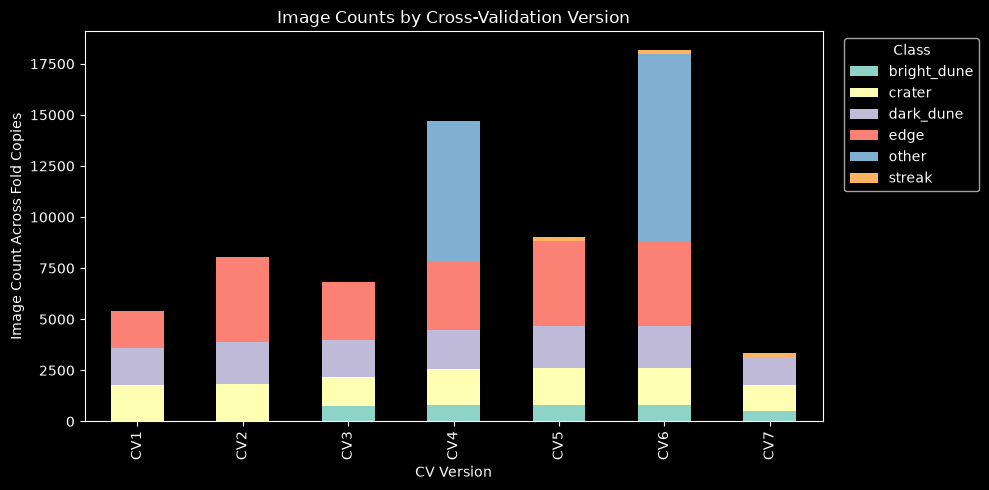

In [7]:
class_totals = (
    inventory.groupby(["cv", "label"], dropna=False)
    .size()
    .rename("image_count")
    .reset_index()
)

pivot = class_totals.pivot(index="cv", columns="label", values="image_count").fillna(0)
pivot.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Image Counts by Cross-Validation Version")
plt.xlabel("CV Version")
plt.ylabel("Image Count Across Fold Copies")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## Image Integrity

In [8]:
inventory["readable"].value_counts(dropna=False)

readable
True    65518
Name: count, dtype: int64

In [9]:
inventory.query("readable == False").head(20)

,cv,version_dir,fold,split,split_dir,label,filename,extension,bytes,width,height,mode,readable,error,path


In [10]:
image_shapes = (
    inventory.groupby(["width", "height", "mode"], dropna=False)
    .size()
    .rename("image_count")
    .reset_index()
    .sort_values("image_count", ascending=False)
)
image_shapes.head(20)

,width,height,mode,image_count
0,227,227,L,65518


## Sample Images

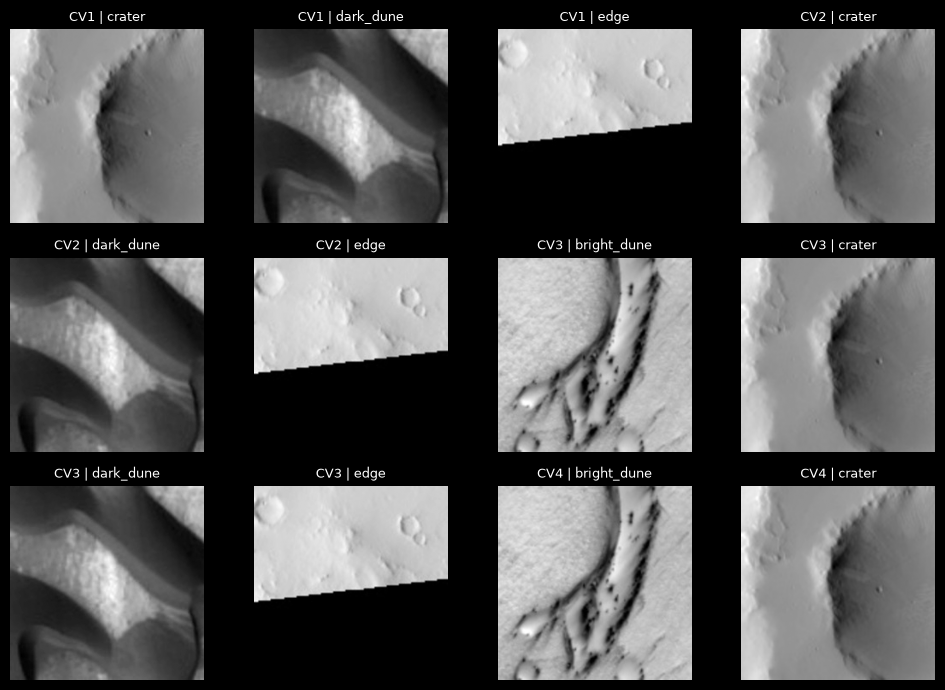

In [11]:
from PIL import Image

samples = (
    inventory.query("readable == True")
    .groupby(["cv", "label"], group_keys=False)
    .head(1)
    .head(12)
)

fig, axes = plt.subplots(3, 4, figsize=(10, 7))
for ax, (_, row) in zip(axes.flat, samples.iterrows()):
    img = Image.open(row["path"])
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row['cv']} | {row['label']}", fontsize=9)
    ax.axis("off")

for ax in axes.flat[len(samples):]:
    ax.axis("off")

plt.tight_layout()